In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.1, use_dropout=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))

        layers.extend([
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ])
        if use_dropout:
            layers.append(nn.Dropout2d(dropout_rate))

        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)

In [6]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

In [7]:
class EfficientNetV2SSEUNet(nn.Module):
    """
    U-Net with a pretrained EfficientNetV2-S encoder + SE attention.
    - SE applied to encoder stages and bottleneck
    - Classification head branches from the bottleneck for damage type (6 classes)
    - Segmentation decoder predicts the defect mask
    """
    def __init__(self, in_channels=3, num_classes=6, dropout_rate=0.15):
        super().__init__()

        try:
            backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        except Exception as exc:
            print(f"Warning: pretrained EfficientNetV2-S weights unavailable ({exc}); using random init.")
            backbone = models.efficientnet_v2_s(weights=None)

        self.features = backbone.features

        for param in self.parameters():
            param.requires_grad = False

        self.att0 = SEBlock(24)
        self.att1 = SEBlock(24)
        self.att2 = SEBlock(48)
        self.att3 = SEBlock(64)
        self.att4 = SEBlock(128)
        self.att_b = SEBlock(1280)

        self.bottleneck = DoubleConv(1280, 512, dropout_rate=0.2, use_dropout=True)
        self.bottleneck_att = SEBlock(512)

        self.avg_pool_cls = nn.AdaptiveAvgPool2d(1)
        self.class_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self.skip4 = nn.Conv2d(128, 128, kernel_size=1)
        self.skip3 = nn.Conv2d(64, 64, kernel_size=1)
        self.skip2 = nn.Conv2d(48, 64, kernel_size=1)
        self.skip1 = nn.Conv2d(24, 32, kernel_size=1)

        self.up4 = nn.ConvTranspose2d(512, 128, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(128 + 128, 128, dropout_rate, use_dropout=True)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(64 + 64, 64, dropout_rate, use_dropout=True)

        self.up2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64 + 64, 64, dropout_rate, use_dropout=True)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32 + 32, 32, dropout_rate, use_dropout=True)

        self.up0 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)

        for module in [self.att0, self.att1, self.att2, self.att3, self.att4, self.att_b,
                       self.bottleneck, self.bottleneck_att, self.class_head, self.skip4, self.skip3, self.skip2, self.skip1,
                       self.up4, self.up3, self.up2, self.up1, self.up0,
                       self.dec1, self.dec2, self.dec3, self.dec4, self.final_conv]:
            for param in module.parameters():
                param.requires_grad = True

    def forward(self, x):
        feats = []
        out = x
        for layer in self.features:
            out = layer(out)
            feats.append(out)

        e0 = self.att0(feats[0])
        e1 = self.att1(feats[1])
        e2 = self.att2(feats[2])
        e3 = self.att3(feats[3])
        e4 = self.att4(feats[4])
        e7 = self.att_b(feats[7])

        b = self.bottleneck(e7)
        b = self.bottleneck_att(b)

        class_logits = self.avg_pool_cls(b)
        class_logits = class_logits.view(class_logits.size(0), -1)
        class_logits = self.class_head(class_logits)

        d4 = self.up4(b)
        d4 = torch.cat([d4, self.skip4(e4)], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, self.skip3(e3)], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, self.skip2(e2)], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, self.skip1(e1)], dim=1)
        d1 = self.dec1(d1)

        d0 = self.up0(d1)
        seg_logits = self.final_conv(d0)

        return seg_logits, class_logits

In [8]:
class MagneticTilesDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.transform = transform
        self.img_size = img_size
        self.pairs = []
        self.class_to_idx = {'MT_Blowhole': 0, 'MT_Break': 1, 'MT_Crack': 2, 'MT_Fray': 3, 'MT_Free': 4, 'MT_Uneven': 5}

        classes = ['MT_Blowhole', 'MT_Break', 'MT_Crack', 'MT_Fray', 'MT_Free', 'MT_Uneven']

        for cls in classes:
            imgs_dir = os.path.join(root_dir, split, cls, 'Imgs')
            gts_dir = os.path.join(root_dir, split, cls, 'GTs')
            if not os.path.isdir(imgs_dir) or not os.path.isdir(gts_dir):
                print(f"Warning: {imgs_dir} or {gts_dir} not found, skipping.")
                continue
            gt_files = set(os.listdir(gts_dir))
            jpg_files = sorted([f for f in os.listdir(imgs_dir) if f.endswith('.jpg')])
            for jpg in jpg_files:
                base = os.path.splitext(jpg)[0]
                png = base + '.png'
                if png in gt_files:
                    self.pairs.append((
                        os.path.join(imgs_dir, jpg),
                        os.path.join(gts_dir, png),
                        self.class_to_idx[cls]
                    ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, gt_path, cls_idx = self.pairs[idx]

        img = Image.open(img_path).convert('RGB')
        label = Image.open(gt_path).convert('L')

        img = img.resize(self.img_size)
        label = label.resize(self.img_size)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = transforms.ToTensor()(label)
        label = (label > 0.5).float()

        return img, label, cls_idx

In [9]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()


def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2, 3))
    denom = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(seg_logits, masks, class_logits, class_labels, bce_weight=0.6, dice_weight=0.4, cls_weight=0.3):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(seg_logits, masks)
    probs = torch.sigmoid(seg_logits)
    dice = DiceLoss()(probs, masks)
    seg_loss = bce_weight * bce + dice_weight * dice

    cls_loss = nn.CrossEntropyLoss()(class_logits, class_labels)

    return seg_loss + cls_weight * cls_loss

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()

    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)

    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0, 1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0, 0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0

    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = (iou + iou_bg) / 2
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)

    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "miou": float(miou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc)}

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for imgs, masks, class_labels in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        class_labels = class_labels.to(device)
        optimizer.zero_grad()
        seg_logits, class_logits = model(imgs)
        loss = combined_loss(seg_logits, masks, class_logits, class_labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

        metrics = compute_metrics_batch(seg_logits, masks)
        running_acc += metrics['acc'] * imgs.size(0)

    if scheduler is not None:
        scheduler.step()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_acc / len(loader.dataset)
    return epoch_loss, epoch_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn": 0, "fp": 0, "fn": 0, "tp": 0}

    y_true_cls = []
    y_pred_cls = []

    for imgs, masks, class_labels in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        class_labels = class_labels.to(device)
        seg_logits, class_logits = model(imgs)
        loss = combined_loss(seg_logits, masks, class_logits, class_labels)
        running_loss += loss.item() * imgs.size(0)
        metas = compute_metrics_batch(seg_logits, masks)
        for k in ["tn", "fp", "fn", "tp"]:
            agg[k] += metas[k]

        preds = class_logits.argmax(dim=1).cpu().numpy()
        y_pred_cls.extend(preds.tolist())
        y_true_cls.extend(class_labels.cpu().numpy().tolist())

    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = (iou + iou_bg) / 2
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)

    epoch_loss = running_loss / len(loader.dataset)

    metrics = {"loss": epoch_loss, "iou": iou, "miou": miou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc,
               "confusion": np.array([[tn, fp], [fn, tp]])}

    labels = list(range(6))
    cm_cls = confusion_matrix(y_true_cls, y_pred_cls, labels=labels)
    per_prec = precision_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)
    per_rec = recall_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)
    per_f1 = f1_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)
    acc_cls = accuracy_score(y_true_cls, y_pred_cls)

    metrics.update({
        'cls_confusion': cm_cls,
        'cls_per_prec': per_prec,
        'cls_per_rec': per_rec,
        'cls_per_f1': per_f1,
        'cls_acc': acc_cls
    })

    return metrics

def plot_confusion_matrix(confusion_matrix, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-damage', 'Damage'],
                yticklabels=['Non-damage', 'Damage'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

Running on Kaggle: True
Loading dataset from: /kaggle/input/datasets/saranjpalani/cvdataset/MagneticTilesDataset_Augmented
Output directory: /kaggle/working
Training samples: 2249
Validation samples: 268
Test samples: 271
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 207MB/s]


Total parameters: 29,851,735
Trainable parameters: 9,674,247
Starting training...

Epoch 1/200


Val batch: 100%|██████████| 134/134 [00:07<00:00, 18.21it/s]


Train Loss: 0.921636 | Train Acc: 0.9292
Val Loss: 0.693256 | Val Acc: 0.9721 | IoU: 0.0000 | Dice: 0.0000 | F1: 0.0000
Learning Rate: 2.00e-04
Val Classification Accuracy: 0.7052
Saved best model with validation loss: 0.693256

Epoch 2/200


...

Train Loss: 0.184610 | Train Acc: 0.9910
Val Loss: 0.168773 | Val Acc: 0.9944 | IoU: 0.8232 | Dice: 0.9030 | F1: 0.9030
Learning Rate: 1.40e-04
Val Classification Accuracy: 0.8806

Epoch 58/200


Val batch: 100%|██████████| 134/134 [00:04<00:00, 32.65it/s]


Train Loss: 0.179021 | Train Acc: 0.9917
Val Loss: 0.167059 | Val Acc: 0.9941 | IoU: 0.8114 | Dice: 0.8959 | F1: 0.8959
Learning Rate: 1.40e-04
Val Classification Accuracy: 0.8993

Epoch 59/200


Val batch: 100%|██████████| 134/134 [00:04<00:00, 31.93it/s]


Train Loss: 0.179741 | Train Acc: 0.9914
Val Loss: 0.157457 | Val Acc: 0.9944 | IoU: 0.8235 | Dice: 0.9032 | F1: 0.9032
Learning Rate: 1.40e-04
Val Classification Accuracy: 0.8993
Early stopping triggered after 59 epochs


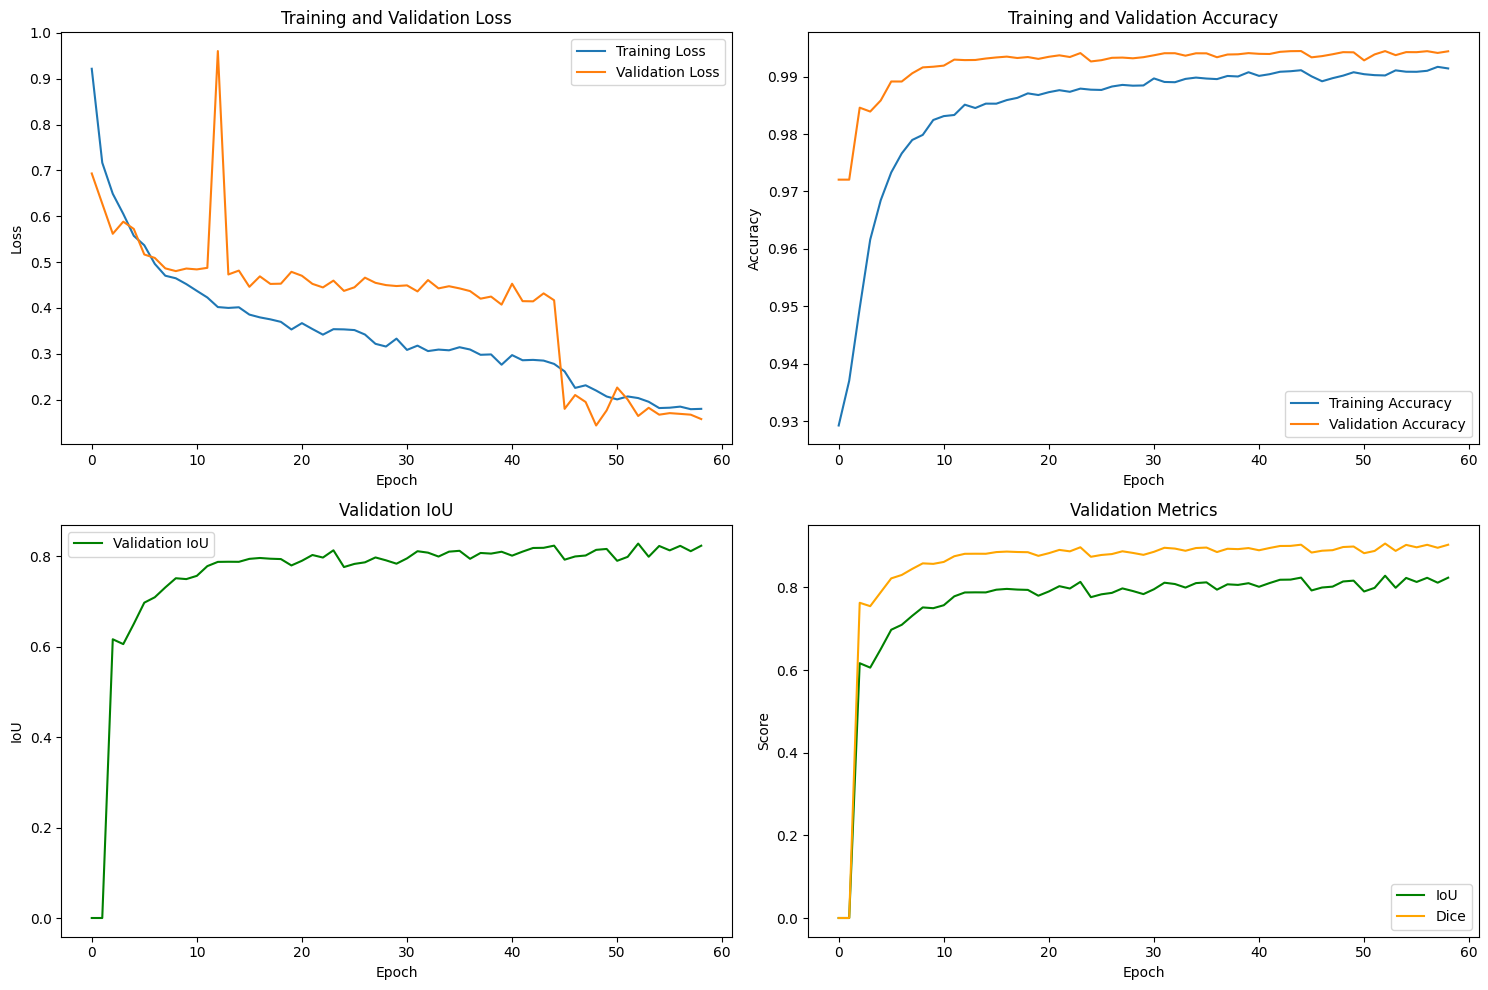

Loading best model for test evaluation...

Evaluating on test set...


Val batch: 100%|██████████| 271/271 [00:11<00:00, 23.06it/s]



EFFICIENTNETV2-S + SE MULTITASK TEST EVALUATION METRICS - MAGNETIC TILES
Test set processed with batch_size=1
Loss:            0.186668
IoU:             0.8046
mIoU:            0.8994
Dice Coefficient: 0.8917
Accuracy:        0.9944
Precision:       0.9315
Recall:          0.8552
F1-Score:        0.8917
Classification Accuracy: 0.8930
Confusion matrix (pixel-level):
[[17251737    30084]
 [   69287   409148]]


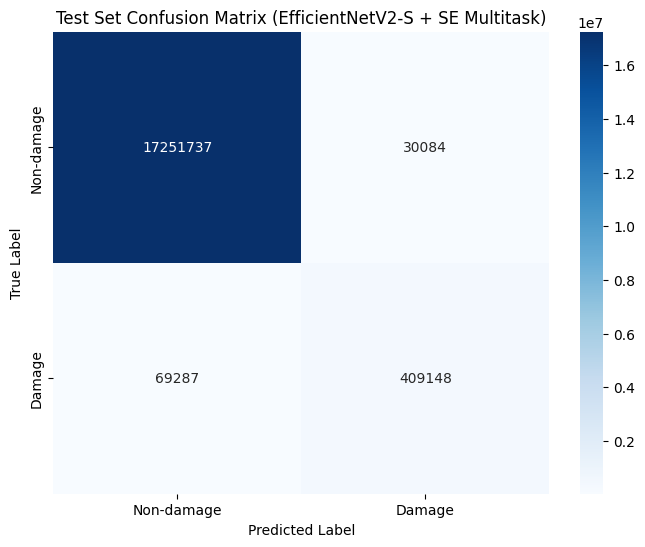

EfficientNetV2-S + SE Multi-Task Magnetic Tiles training and evaluation completed!


In [11]:
def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=learning_rate)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )

    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    val_ious = []
    val_dices = []
    val_cls_accs = []

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_metrics = validate(model, val_loader)

        scheduler.step(val_metrics['loss'])

        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"Val Classification Accuracy: {val_metrics['cls_acc']:.4f}")

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_metrics['loss'])
        val_accs.append(val_metrics['acc'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        val_cls_accs.append(val_metrics.get('cls_acc'))

        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'best_multitask_efficientnetv2s_se.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")

        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break

    return train_losses, train_accs, val_losses, val_accs, val_ious, val_dices, val_cls_accs

def main():
    BATCH_SIZE = 6
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 200
    PATIENCE = 10
    IMG_SIZE = (256, 256)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    import pathlib
    notebook_dir = pathlib.Path.cwd()
    is_kaggle = str(notebook_dir).startswith("/kaggle")

    if is_kaggle:
        output_dir = pathlib.Path("/kaggle/working")
        root_dir = pathlib.Path("/kaggle/input/datasets/saranjpalani/cvdataset/MagneticTilesDataset_Augmented")
        if not root_dir.exists():
            root_dir = output_dir
    else:
        output_dir = notebook_dir
        augmented_path = notebook_dir / "MagneticTilesDataset_Augmented"
        if augmented_path.exists():
            root_dir = augmented_path
        else:
            root_dir = notebook_dir

    print(f"Running on Kaggle: {is_kaggle}")
    print(f"Loading dataset from: {root_dir}")
    print(f"Output directory: {output_dir}")

    train_dataset = MagneticTilesDataset(str(root_dir), split="train", transform=transform, img_size=IMG_SIZE)
    val_dataset = MagneticTilesDataset(str(root_dir), split="val", transform=transform, img_size=IMG_SIZE)
    test_dataset = MagneticTilesDataset(str(root_dir), split="test", transform=transform, img_size=IMG_SIZE)

    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    if len(train_dataset) == 0:
        raise ValueError(f"No training samples found at {root_dir}. Check the dataset structure.")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

    model = EfficientNetV2SSEUNet(in_channels=3, num_classes=6, dropout_rate=0.15).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    print("Starting training...")
    train_losses, train_accs, val_losses, val_accs, val_ious, val_dices, val_cls_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    ax1.plot(train_losses, label="Training Loss")
    ax1.plot(val_losses, label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.set_title("Training and Validation Loss")

    ax2.plot(train_accs, label="Training Accuracy")
    ax2.plot(val_accs, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.set_title("Training and Validation Accuracy")

    ax3.plot(val_ious, label="Validation IoU", color="green")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("IoU")
    ax3.legend()
    ax3.set_title("Validation IoU")

    ax4.plot(val_ious, label="IoU", color="green")
    ax4.plot(val_dices, label="Dice", color="orange")
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Score")
    ax4.legend()
    ax4.set_title("Validation Metrics")

    plt.tight_layout()
    plt.savefig(str(output_dir / "training_curves_efficientnetv2s_se_multitask.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load("best_multitask_efficientnetv2s_se.pth", map_location=device))
    model.to(device)

    print("\nEvaluating on test set...")
    test_metrics = validate(model, test_loader)

    print("\n" + "=" * 50)
    print("EFFICIENTNETV2-S + SE MULTITASK TEST EVALUATION METRICS - MAGNETIC TILES")
    print("=" * 50)
    print(f"Test set processed with batch_size=1")
    print(f"Loss:            {test_metrics['loss']:.6f}")
    print(f"IoU:             {test_metrics['iou']:.4f}")
    print(f"mIoU:            {test_metrics['miou']:.4f}")
    print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
    print(f"Accuracy:        {test_metrics['acc']:.4f}")
    print(f"Precision:       {test_metrics['precision']:.4f}")
    print(f"Recall:          {test_metrics['recall']:.4f}")
    print(f"F1-Score:        {test_metrics['f1']:.4f}")
    print(f"Classification Accuracy: {test_metrics['cls_acc']:.4f}")
    print("Confusion matrix (pixel-level):")
    print(test_metrics["confusion"])
    print("=" * 50)

    plot_confusion_matrix(test_metrics["confusion"], "Test Set Confusion Matrix (EfficientNetV2-S + SE Multitask)")

    print("EfficientNetV2-S + SE Multi-Task Magnetic Tiles training and evaluation completed!")


if __name__ == "__main__":
    main()